In [1]:
# Imports & configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)


In [2]:
# Chargement des transactions

df = pd.read_csv("../datasets/transactions_50000.csv", parse_dates=["timestamp"])
df.head()


,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud
0,aaed9bfe-7236-4689-9fc6-741a0dbece2b,a91b1faa-818e-4203-8239-31e783e48d70,5627f9ab-fc29-43e2-a85e-94f1d445a66c,2025-01-01 00:00:37,3,309,33.810968,0
1,5612b999-a331-44c4-a790-ed90895e610e,63aa7929-6bb2-454a-b2a0-49c8a39a4a6b,36ed8e8a-a7cb-47dd-96a5-17b5fb98f2c7,2025-01-01 00:19:12,3,165,131.372129,0
2,fa48eb0b-5093-476a-9f23-267c036fff66,c3aa994e-1bdd-49f6-98b2-5cebd8302a51,3fa7683f-bce7-4f97-a9bc-358e518dc319,2025-01-01 01:01:56,1,128,5.852311,0
3,b0d812d3-13d2-4283-b44c-e8ac862b0fbb,75016216-5c60-42d3-8f02-b91e39ed0839,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:09:33,1,53,247.619547,0
4,4100fea3-ed4f-4153-9823-aa0c65611ce9,56f47b1b-acfa-4db9-a72b-70723a35200b,a6a50633-3e55-4873-bc45-86aafc8fa1fe,2025-01-01 01:23:24,2,106,75.959480,0


In [3]:
# Préparation des données par événement

# Tri chronologique
df = df.sort_values(["event_id", "timestamp"])

# Ventes cumulées par événement
df["tickets_cumules"] = df.groupby("event_id")["nb_tickets"].cumsum()

df.head()


,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud,tickets_cumules
17,f4b40eeb-e33d-4327-93e5-280fe4387bb7,559b8c08-aad6-4b8b-b8ce-b909533ed7a4,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 04:46:27,2,58,20.093642,0,2
21,3e90ba17-9c33-46e5-8096-2993f519494c,ba772b85-0211-4cab-9393-f3aeea43753b,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 05:40:27,1,29,483.827274,0,3
34,5c295d10-916e-4493-91d4-6a90d33087d1,dac68838-4306-4982-98ab-9fd33069d7af,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 07:18:44,1,29,174.389461,0,4
43,dc4a0efe-86e7-44bc-a68d-a23671b40357,d9c2a794-65a3-45a2-b225-8a8d1a6c0759,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 08:41:38,2,58,306.337223,0,6
81,68563a2b-3ecd-45a2-98e1-cecbdd344c60,b0f43dd8-ff39-4ce0-81ce-7a0bfd052033,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 17:17:11,1,29,1.191865,1,7


In [4]:
# Calcul de la vélocité (tickets/minute)

df["delta_seconds"] = df.groupby("event_id")["timestamp"].diff().dt.total_seconds()
df["delta_seconds"] = df["delta_seconds"].fillna(999999)

# Vélocité = tickets vendus / temps écoulé
df["velocity_tpm"] = df["nb_tickets"] / (df["delta_seconds"] / 60)
df["velocity_tpm"] = df["velocity_tpm"].replace([np.inf, -np.inf], 0).fillna(0)

df.head()


,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud,tickets_cumules,delta_seconds,velocity_tpm
17,f4b40eeb-e33d-4327-93e5-280fe4387bb7,559b8c08-aad6-4b8b-b8ce-b909533ed7a4,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 04:46:27,2,58,20.093642,0,2,999999.0,0.000120
21,3e90ba17-9c33-46e5-8096-2993f519494c,ba772b85-0211-4cab-9393-f3aeea43753b,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 05:40:27,1,29,483.827274,0,3,3240.0,0.018519
34,5c295d10-916e-4493-91d4-6a90d33087d1,dac68838-4306-4982-98ab-9fd33069d7af,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 07:18:44,1,29,174.389461,0,4,5897.0,0.010175
43,dc4a0efe-86e7-44bc-a68d-a23671b40357,d9c2a794-65a3-45a2-b225-8a8d1a6c0759,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 08:41:38,2,58,306.337223,0,6,4974.0,0.024125
81,68563a2b-3ecd-45a2-98e1-cecbdd344c60,b0f43dd8-ff39-4ce0-81ce-7a0bfd052033,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 17:17:11,1,29,1.191865,1,7,30933.0,0.001940


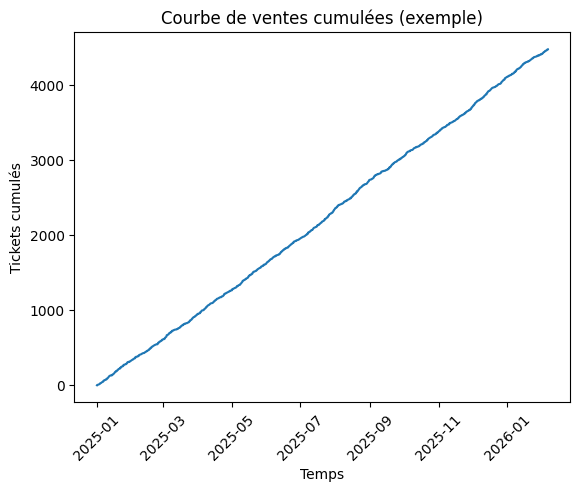

In [5]:
# Visualisation d’un événement

event_sample = df[df["event_id"] == df["event_id"].iloc[0]]

plt.plot(event_sample["timestamp"], event_sample["tickets_cumules"])
plt.title("Courbe de ventes cumulées (exemple)")
plt.xlabel("Temps")
plt.ylabel("Tickets cumulés")
plt.xticks(rotation=45)
plt.show()


In [6]:
# Construction du dataset de régression

# On veut prédire le temps restant avant sold‑out.
#Hypothèse :

#Chaque événement a une capacité max (simulée ici).

# Capacité simulée (si non présente dans le dataset)
capacite_event = df.groupby("event_id")["tickets_cumules"].max().reset_index()
capacite_event.columns = ["event_id", "capacite_max"]

# Fusion
df = df.merge(capacite_event, on="event_id", how="left")


In [7]:
# Calcul de la cible : temps restant avant sold‑out

# Temps du sold-out pour chaque event
soldout_times = df.groupby("event_id")["timestamp"].max().reset_index()
soldout_times.columns = ["event_id", "soldout_time"]

df = df.merge(soldout_times, on="event_id", how="left")

# Cible : temps restant avant sold-out (en minutes)
df["time_to_soldout_min"] = (df["soldout_time"] - df["timestamp"]).dt.total_seconds() / 60

df = df[df["time_to_soldout_min"] > 0]  # on garde les points avant sold-out
df.head()


,order_id,user_id,event_id,timestamp,nb_tickets,montant,velocity_seconds,is_fraud,tickets_cumules,delta_seconds,velocity_tpm,capacite_max,soldout_time,time_to_soldout_min
0,f4b40eeb-e33d-4327-93e5-280fe4387bb7,559b8c08-aad6-4b8b-b8ce-b909533ed7a4,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 04:46:27,2,58,20.093642,0,2,999999.0,0.000120,4481,2026-02-05 23:37:59,577131.533333
1,3e90ba17-9c33-46e5-8096-2993f519494c,ba772b85-0211-4cab-9393-f3aeea43753b,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 05:40:27,1,29,483.827274,0,3,3240.0,0.018519,4481,2026-02-05 23:37:59,577077.533333
2,5c295d10-916e-4493-91d4-6a90d33087d1,dac68838-4306-4982-98ab-9fd33069d7af,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 07:18:44,1,29,174.389461,0,4,5897.0,0.010175,4481,2026-02-05 23:37:59,576979.250000
3,dc4a0efe-86e7-44bc-a68d-a23671b40357,d9c2a794-65a3-45a2-b225-8a8d1a6c0759,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 08:41:38,2,58,306.337223,0,6,4974.0,0.024125,4481,2026-02-05 23:37:59,576896.350000
4,68563a2b-3ecd-45a2-98e1-cecbdd344c60,b0f43dd8-ff39-4ce0-81ce-7a0bfd052033,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 17:17:11,1,29,1.191865,1,7,30933.0,0.001940,4481,2026-02-05 23:37:59,576380.800000


In [8]:
# Sélection des features

feature_cols = [
    "tickets_cumules",
    "velocity_tpm",
    "nb_tickets",
    "delta_seconds"
]

X = df[feature_cols]
y = df["time_to_soldout_min"]


In [9]:
# Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# Entraînement du modèle (RandomForest)
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Évaluation

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("MAE (minutes) :", mae)
print("MAE (heures) :", mae / 60)


MAE (minutes) : 7396.295929781517
MAE (heures) : 123.27159882969195


In [12]:
# Prédiction du sold-out en temps réel

df["pred_time_to_soldout_min"] = model.predict(df[feature_cols])

df["soldout_time_pred"] = df["timestamp"] + pd.to_timedelta(
    df["pred_time_to_soldout_min"], unit="m"
)

df_predictions = df[[
    "event_id",
    "timestamp",
    "tickets_cumules",
    "velocity_tpm",
    "pred_time_to_soldout_min",
    "soldout_time_pred"
]]

df_predictions.head()


,event_id,timestamp,tickets_cumules,velocity_tpm,pred_time_to_soldout_min,soldout_time_pred
0,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 04:46:27,2,0.000120,576907.835875,2026-02-05 19:54:17.152510950
1,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 05:40:27,3,0.018519,576734.658754,2026-02-05 17:55:06.525268848
2,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 07:18:44,4,0.010175,576498.864507,2026-02-05 15:37:35.870423624
3,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 08:41:38,6,0.024125,576593.831343,2026-02-05 18:35:27.880574282
4,03c85729-9363-4cd6-823d-bb9981e6a0eb,2025-01-01 17:17:11,7,0.001940,575821.675777,2026-02-05 14:18:51.546608630


In [13]:
# Export pour le dashboard

output_path = "../datasets/soldout_prediction.csv"
df_predictions.to_csv(output_path, index=False)

print("Fichier exporté :", output_path)
print("Nombre de lignes :", len(df_predictions))


Fichier exporté : ../datasets/soldout_prediction.csv
Nombre de lignes : 49980
